Bollywood Box Office Revenue Analysis

Authors
Dev Bhardwaj  
Ishi Goel  
Aaryan Dubey  

This project analyzes the financial factors influencing the worldwide box office performance of Bollywood movies. The dataset contains information about the top 1000 Bollywood movies including budget, domestic earnings, overseas collections and worldwide revenue.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

sns.set(style="whitegrid")

In [46]:
df = pd.read_csv("Top 1000 Bollywood Movies and their boxoffice.csv")

df.head()

,Unnamed: 0,SN,Movie,Worldwide,India Net,India Gross,Overseas,Budget,Verdict
0,0,1,Pathaan,10500000000,5240000000,6570000000,3920000000,2500000000,All Time Blockbuster
1,1,2,Baahubali 2 The Conclusion,17880000000,5100000000,14160000000,3710000000,2500000000,All Time Blockbuster
2,2,3,KGF Chapter 2,12080000000,4350000000,10000000000,2070000000,1000000000,All Time Blockbuster
3,3,4,Dangal,20700000000,3740000000,5350000000,15350000000,700000000,All Time Blockbuster
4,4,5,Sanju,5880000000,3420000000,4380000000,1500000000,1000000000,All Time Blockbuster


In [47]:
df = df[['Worldwide','Budget','India Net','India Gross','Overseas']]

df = df.dropna()

df.head()

,Worldwide,Budget,India Net,India Gross,Overseas
0,10500000000,2500000000,5240000000,6570000000,3920000000
1,17880000000,2500000000,5100000000,14160000000,3710000000
2,12080000000,1000000000,4350000000,10000000000,2070000000
3,20700000000,700000000,3740000000,5350000000,15350000000
4,5880000000,1000000000,3420000000,4380000000,1500000000


 Data Cleaning

For this analysis, only the relevant financial variables were selected. 
These include worldwide revenue, movie budget, India Net collection, 
India Gross collection, and overseas collection.

Rows containing missing values were removed to ensure the dataset is 
complete and suitable for statistical analysis and modeling.

In [48]:
df.describe()

,Worldwide,Budget,India Net,India Gross,Overseas
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,1.832870e+09,5.889000e+08,4.079600e+08,6.126900e+08,9.714300e+08
std,1.049006e+10,2.101992e+09,5.783055e+08,9.814085e+08,8.596981e+09
min,0.000000e+00,0.000000e+00,2.000000e+07,0.000000e+00,0.000000e+00
25%,1.600000e+08,8.000000e+07,9.000000e+07,1.400000e+08,1.000000e+07
50%,3.700000e+08,2.000000e+08,2.000000e+08,3.100000e+08,5.000000e+07
75%,9.025000e+08,4.000000e+08,4.600000e+08,6.825000e+08,1.500000e+08
max,1.897000e+11,3.200000e+10,5.240000e+09,1.416000e+10,1.690200e+11


Interpretation

The summary statistics provide insights into the distribution of movie 
budgets and box office revenues. The dataset shows significant variation 
in worldwide earnings and production budgets, indicating that Bollywood 
films differ greatly in scale and financial success.

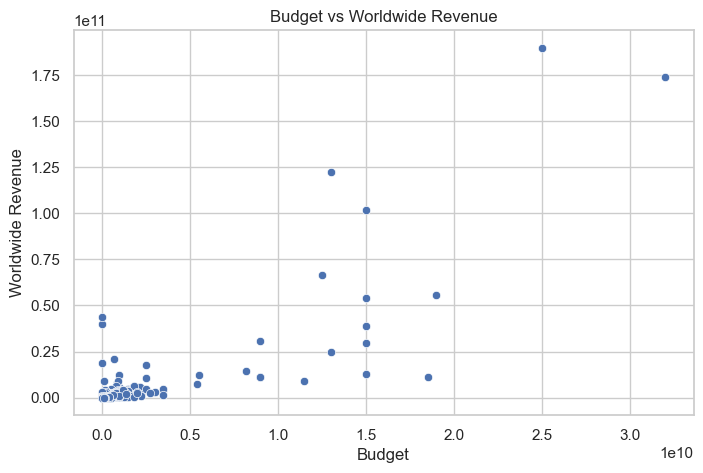

In [49]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Budget'], y=df['Worldwide'])
plt.title("Budget vs Worldwide Revenue")
plt.xlabel("Budget")
plt.ylabel("Worldwide Revenue")
plt.show()

Interpretation

This scatter plot shows the relationship between production budget and 
worldwide box office revenue. Although higher budgets often lead to 
larger revenues, the relationship is not perfectly linear. Some 
lower-budget films also achieve strong financial performance.

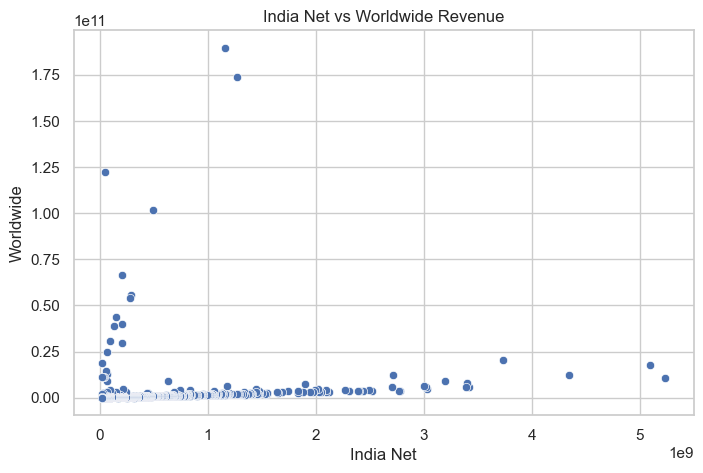

In [50]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['India Net'], y=df['Worldwide'])
plt.title("India Net vs Worldwide Revenue")
plt.show()

Movies that perform strongly in the domestic Indian market tend to 
generate higher worldwide revenue. This suggests that domestic 
audience reception plays a significant role in determining the 
global success of Bollywood films.

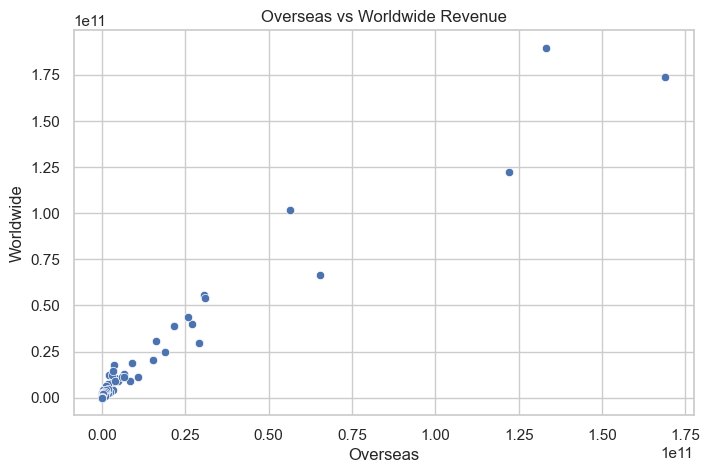

In [51]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Overseas'], y=df['Worldwide'])
plt.title("Overseas vs Worldwide Revenue")
plt.show()

The scatter plot indicates a positive relationship between overseas 
collections and worldwide revenue. Bollywood movies that perform 
well internationally contribute significantly to overall box office earnings.

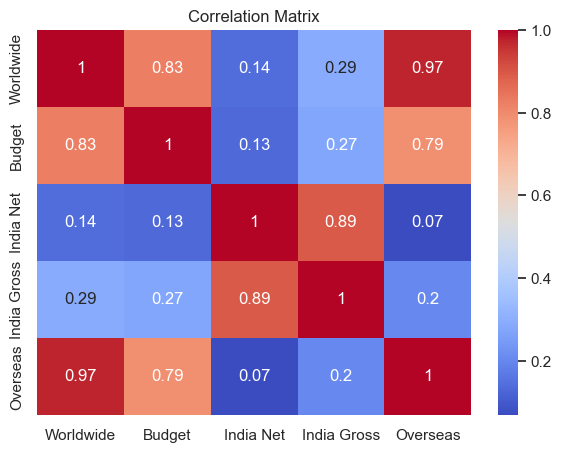

In [52]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows strong positive relationships between 
domestic earnings, overseas collections, and worldwide revenue. 
This highlights the importance of both domestic and international 
markets in determining the financial success of Bollywood films.

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['Budget','India Net','India Gross','Overseas']]
y = df['Worldwide']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()

model.fit(X_train,y_train)

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test,predictions))

R2 Score: 0.9549866544826481


A linear regression model was developed to predict worldwide box office 
revenue using variables such as production budget, domestic collections, 
and overseas earnings.

The R² score indicates how well these variables explain the variation 
in worldwide revenue.

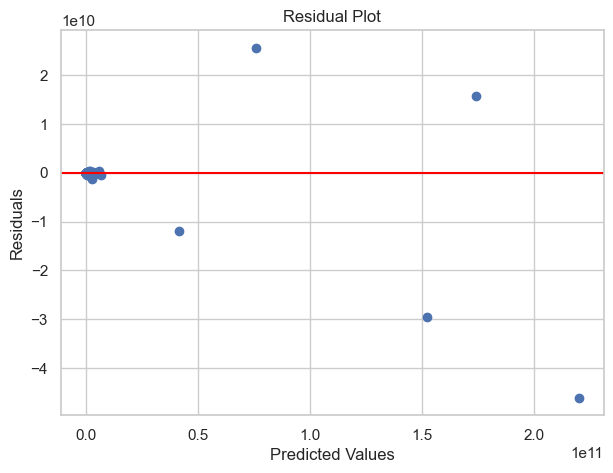

In [54]:
residuals = y_test - predictions

plt.figure(figsize=(7,5))
plt.scatter(predictions,residuals)
plt.axhline(y=0,color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residual plot shows the difference between the actual and predicted 
values of worldwide revenue. Ideally, residuals should be randomly 
distributed around zero, indicating that the regression model captures 
the relationship effectively without systematic bias.


Conclusion

This project analyzed financial factors influencing the worldwide box office performance of Bollywood movies.

The analysis showed that domestic collections and overseas earnings have strong relationships with worldwide revenue. Although production budget plays an important role, it does not guarantee success. Audience reception and international reach are key determinants of a movie's financial performance.